# 1. df['Income'].quantile(0.75) returns?
a. Median b. 75th percentile c. IQR d. Standard Deviation

Answer :- 75th percentile

# 2. Which method calculates correlation matrix in pandas?
a. df.corrcoef() b. df.correlation() c. df.corr() d. df.rel()

Answer :- df.corr()

# 3. Correlation = -0.85 indicates:
a. Weak positive b. Strong negative c. No relationship d. Independence

Answer :- Strong negative

# 4. Best plot to compare distribution across categories?
a. Line plot b. Pie chart c. Count plot d. Histogram

Answer :- Count plot

# 5. Correct IQR outlier detection formula:
a. x < Q1 - 1.5*IQR OR x > Q3 + 1.5*IQR b. x < mean - std c. x > variance d. x == median

Answer :- x < Q1 - 1.5*IQR OR x > Q3 + 1.5*IQR

# 6. df.groupby('City')['Income'].mean() returns:
a. Overall mean b. Mean income per city c. Median per city d. Std per city

Answer :- Mean income per city

# 7. Sampling method selecting every kth observation:
a. Random b. Stratified c. Systematic d. Cluster

Answer :- Systematic

# 8. Purpose of np.random.seed(42):
a. Increase randomness b. Fix randomness c. Remove randomness d. Generate more samples

Answer :- Fix randomness

# 9. High variance indicates:
a. Data tightly clustered b. Data widely spread c. High mean d. High median

Answer :- Data widely spread

# 10. Function to compute standard deviation in pandas:
a. df.std() b. df.var() c. df.describe() d. df.spread()

Answer :- df.std()

# 11. Q1 corresponds to:
a. 10th percentile b. 25th percentile c. 50th percentile d. 75th percentile

Answer :- 25th percentile

# 12. Best plot to visually detect correlation:
a. Pie b. Box c. Heatmap d. Histogram

Answer :- Box

# 13. Marginal probability refers to:
a. Probability of single event b. Conditional probability c. Joint probability d. Complement

Answer :- Probability of single event

# 14. Stratified sampling means:
a. Sample one group b. Divide into strata & sample each d. Random only d. Systematic only

Answer :- Divide into strata & sample each

# 15. Interquartile Range measures:
a. Total range b. Middle 50% spread c. Std deviation d. Mean deviation

Answer :- Middle 50% spread

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "CustomerID": range(1, 101),
    "Age": np.random.randint(18, 65, 100),
    "Income": np.random.randint(20000, 120000, 100),
    "SpendingScore": np.random.randint(1, 100, 100),
    "Gender": np.random.choice(["Male", "Female"], 100),
    "City": np.random.choice(["Delhi", "Mumbai", "Kolkata", "Chennai"], 100),
    "Purchased": np.random.choice([0,1], 100)
}

df = pd.DataFrame(data)

In [2]:
df

,CustomerID,Age,Income,SpendingScore,Gender,City,Purchased
0,1,56,22695,62,Female,Mumbai,1
1,2,46,68190,58,Female,Kolkata,1
2,3,32,25258,52,Male,Mumbai,1
3,4,60,107538,12,Male,Mumbai,1
4,5,25,59504,39,Male,Kolkata,0
...,...,...,...,...,...,...,...
95,96,24,113557,72,Female,Kolkata,1
96,97,26,81087,36,Male,Chennai,1
97,98,41,115839,38,Female,Chennai,1
98,99,18,88840,84,Female,Chennai,1


# 16. Write Python code to compute Mean, Median, Mode of Income and Variance & Std of Age using pandas.

In [3]:
mean_income = df["Income"].mean()
median_income = df["Income"].median()
mode_income = df["Income"].mode()[0]
var_age = df["Age"].var()
std_age = df["Age"].std()

# 17. Write code to detect outliers in Income using IQR method.

In [5]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR
outliers = df[(df["Income"] < LB) | (df["Income"] > UB)] 

# 18. Create Histogram of Income, Boxplot of SpendingScore, Scatter plot of Age vs Income.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

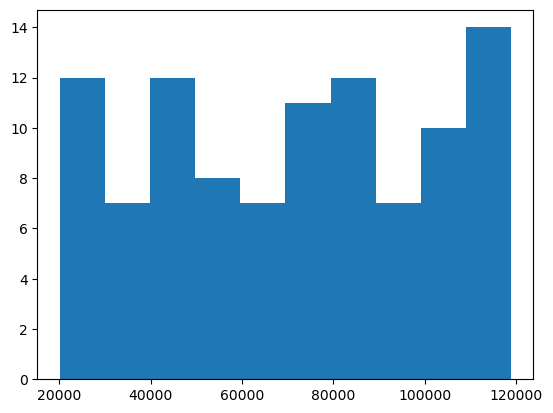

In [7]:
# Histogram
plt.hist(df["Income"])
plt.show()

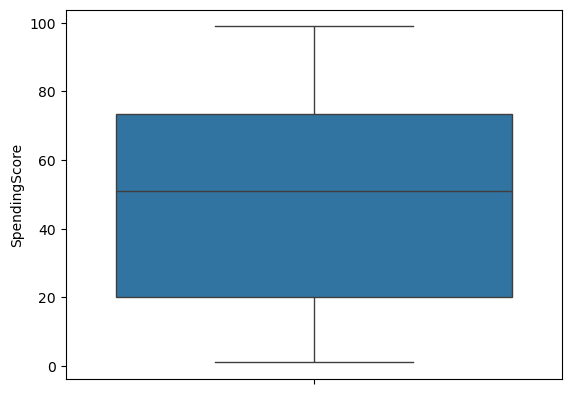

In [8]:
# Boxplot
sns.boxplot(df["SpendingScore"])
plt.show()

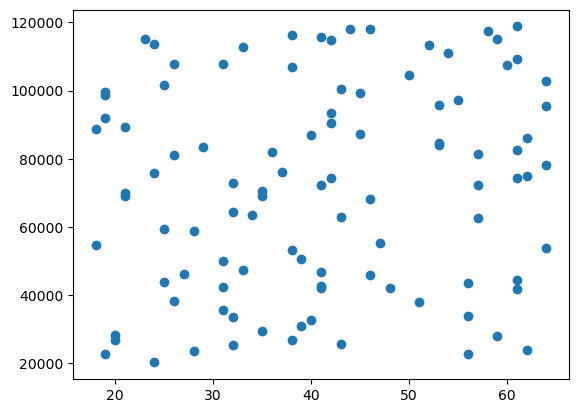

In [9]:
# Scatter plot
plt.scatter(x = df["Age"], y = df["Income"])
plt.show()

# 19. Perform stratified sampling based on Gender (50% sample).

In [10]:
male_df = df[df["Gender"] == "Male"]
female_df = df[df["Gender"] == "Female"]

In [11]:
male_df.shape

(49, 7)

In [13]:
female_df.shape

(51, 7)

In [14]:
male_sample = male_df.sample(25)
female_sample = female_df.sample(25)

In [17]:
final_sample = pd.concat([male_sample, female_sample])
final_sample.shape

(50, 7)

# 20. Compute P(Purchased=1) and P(Purchased=1 | Gender=Female).

In [18]:
df.head()

,CustomerID,Age,Income,SpendingScore,Gender,City,Purchased
0,1,56,22695,62,Female,Mumbai,1
1,2,46,68190,58,Female,Kolkata,1
2,3,32,25258,52,Male,Mumbai,1
3,4,60,107538,12,Male,Mumbai,1
4,5,25,59504,39,Male,Kolkata,0


In [21]:
# P(Purchased=1)
p_purchased_1 = (df["Purchased"] == 1).mean()   # len(df[df["Purchased"] == 1) / len(df)
p_purchased_1

np.float64(0.55)

In [22]:
# P(Purchased=1 | Gender=Female)
female_df = df[df["Gender"] == "Female"]

In [24]:
female_purchased_1 = (female_df["Purchased"] == 1).mean() #p2 = ((df["Gender"] == "Female") & (df["Purchased"] == 1)).sum() / (df["Gender"] == "Female").sum()
female_purchased_1

np.float64(0.5490196078431373)

# 21. Group by City and calculate average Income and SpendingScore.

In [26]:
city_avg = df.groupby("City")[["Income", "SpendingScore"]].mean().reset_index()
city_avg

,City,Income,SpendingScore
0,Chennai,76038.888889,51.851852
1,Delhi,81891.444444,51.833333
2,Kolkata,65212.750000,54.916667
3,Mumbai,65122.419355,39.580645


# 22. Create violin plot of Income by Gender.

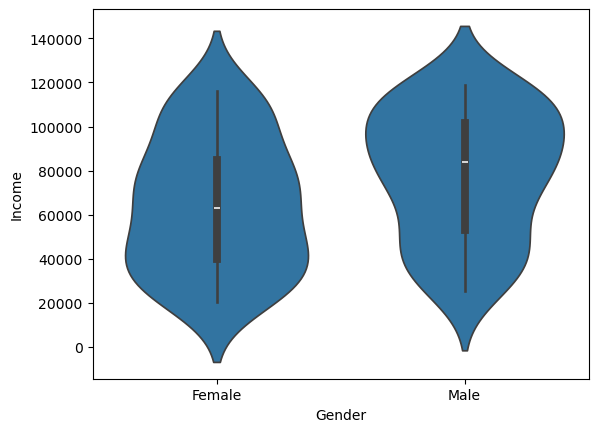

In [27]:
sns.violinplot(data = df, x = "Gender", y = "Income")
plt.show()

# 23. Compute Q1, Q2, Q3 and IQR of Income.

In [28]:
Q1 = df["Income"].quantile(0.25)
Q2 = df["Income"].quantile(0.50)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1

# 24. Simulate systematic sampling (select every 5th record).

In [29]:
syst_samples = df.iloc[ : : 5]

In [31]:
syst_samples

,CustomerID,Age,Income,SpendingScore,Gender,City,Purchased
0,1,56,22695,62,Female,Mumbai,1
5,6,38,53159,2,Male,Chennai,0
10,11,28,23561,2,Female,Kolkata,1
15,16,20,28392,96,Male,Kolkata,0
20,21,47,55222,53,Female,Chennai,1
25,26,29,83335,32,Female,Chennai,0
30,31,59,28110,17,Female,Mumbai,1
35,36,61,118806,70,Male,Delhi,0
40,41,26,107897,73,Female,Chennai,1
45,46,31,107939,3,Female,Chennai,0
